In [1]:
%matplotlib inline
import numpy as np
import torch, torch.nn as nn
import pandas as pd
import cantera as ct
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


In [41]:
JOINT_RESULT = 'result_1398k_joint_train6.pt'
H2O_CSV      = 'hong_1398K_h2o.csv'
OH_CSV       = 'hong_1398K_oh.csv'
YAML_FILE    = 'chem_cti_toy_model_og.yaml'

SIG_LOG     = 0.05
NOISE_FLOOR = 1e-12
LOG_EPS     = 1e-12
INPUT_DIM   = 4
PARAM_NAMES = ['lnA_R1', 'Ea_R1', 'lnA_R2', 'Ea_R2']

SYNTHETIC = False
X_TRUE    = np.array([0.05, 0.0, -0.05, 0.0])  # only used when SYNTHETIC=True

IDX_R1 = 21   # H2O2(+M) <-> OH+OH(+M)  falloff
IDX_R2 = 25   # H2O2+OH  <-> HO2+H2O    Arrhenius

# 1398 K condition -- was left at the 1192 K values (T/P/mixture) copied from
# optimize_1192k_joint_nn.ipynb, which meant every Cantera run in this notebook
# (nominal, MAP, and the FD Jacobian) simulated the WRONG shock-tube condition
# even though JOINT_RESULT/H2O_CSV/OH_CSV already pointed at the 1398 K files.
T_INITIAL = 1398
P_INITIAL = 1.91 * ct.one_atm
INITIAL_X = {'H2O2': 2540e-6, 'H2O': 1234e-6, 'O2': 617e-6,
             'AR': 1.0 - (2540 + 1234 + 617) * 1e-6}

DT_SIM  = 1e-6
N_STEPS = 1000
T_SIM   = np.linspace(DT_SIM, DT_SIM * N_STEPS, N_STEPS)  # 1 us ... 1 ms
T_OH    = np.concatenate([
    np.linspace(1e-7, 2e-4, 600),
    np.linspace(2e-4 + 5e-6, 1e-3, 200),
])


In [42]:
class SurrogateNN(nn.Module):
    def __init__(self, hidden, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden), nn.ReLU(), nn.Linear(hidden, n_out))
    def forward(self, x): return self.net(x)


ckpt       = torch.load(JOINT_RESULT, weights_only=False)
N_OH       = int(ckpt["n_oh_targets"])
N_H2O      = int(ckpt["n_h2o_targets"])
N_TOTAL    = N_OH + N_H2O
oh_times   = np.asarray(ckpt["oh_target_times"])
h2o_times  = np.asarray(ckpt["h2o_target_times"])
OH_LABELS  = ckpt.get("oh_labels",  [f"OH_{i}"  for i in range(N_OH)])
H2O_LABELS = ckpt.get("h2o_labels", [f"H2O_{i}" for i in range(N_H2O)])
hidden_dim = int(ckpt["hidden_dim"])
LN_F       = float(ckpt["ln_f"])
SIGMA_E    = float(ckpt["sigma_e"])

model = SurrogateNN(hidden=hidden_dim, n_out=N_TOTAL)
model.load_state_dict(ckpt["model_state"])
model.eval()

print(f"Loaded: {JOINT_RESULT}")
print(f"Architecture : 4 -> {hidden_dim} -> {N_TOTAL}  (OH: {N_OH}, H2O: {N_H2O})")
print(f"LN_F={LN_F}  SIGMA_E={SIGMA_E}")
print(f"OH  target times (ms): {np.round(oh_times*1e3, 4)}")
print(f"H2O target times (ms): {np.round(h2o_times*1e3, 4)}")


Loaded: result_1398k_joint_train6.pt
Architecture : 4 -> 16 -> 6  (OH: 3, H2O: 3)
LN_F=2.302585092994046  SIGMA_E=5000.0
OH  target times (ms): [0.001  0.0122 0.0179]
H2O target times (ms): [0.0032 0.0082 0.0133]


In [43]:
mol_units = ct.UnitSystem({"length":"cm","mass":"g","time":"s","quantity":"mol",
    "pressure":"dyn / cm^2","energy":"erg","temperature":"K","current":"A",
    "activation-energy":"cal / mol"})

_g = ct.Solution(YAML_FILE)
NOM_A_R1  = _g.reaction(IDX_R1).rate.low_rate.pre_exponential_factor
NOM_B_R1  = _g.reaction(IDX_R1).rate.low_rate.temperature_exponent
NOM_EA_R1 = mol_units.convert_activation_energy_to(
    f"{_g.reaction(IDX_R1).rate.low_rate.activation_energy} J/kmol", "cal / mol")
NOM_A_R2  = _g.reaction(IDX_R2).rate.pre_exponential_factor
NOM_B_R2  = _g.reaction(IDX_R2).rate.temperature_exponent
NOM_EA_R2 = mol_units.convert_activation_energy_to(
    f"{_g.reaction(IDX_R2).rate.activation_energy} J/kmol", "cal / mol")
del _g
print(f"R1: A={NOM_A_R1:.3e}  Ea={NOM_EA_R1:.0f} cal/mol")
print(f"R2: A={NOM_A_R2:.3e}  Ea={NOM_EA_R2:.0f} cal/mol")


R1: A=2.490e+21  Ea=48749 cal/mol
R2: A=7.590e+10  Ea=7270 cal/mol


H2O data time range: 0 .. 0.0998 ms
OH  data time range: 0 .. 0.0999 ms


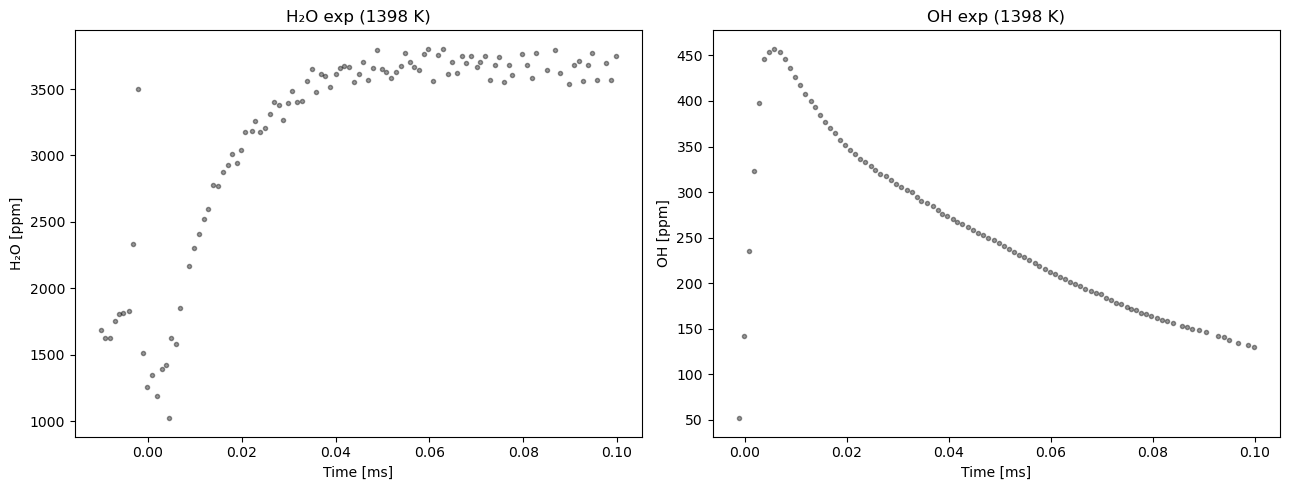

In [44]:
df_h2o = pd.read_csv(H2O_CSV, skipinitialspace=True)
df_oh  = pd.read_csv(OH_CSV,  skipinitialspace=True)

h2o_agg = df_h2o.groupby("Time [ms]")["[H2O] ppm"].mean().reset_index()
t_h2o   = h2o_agg["Time [ms]"].values * 1e-3
y_h2o   = h2o_agg["[H2O] ppm"].values * 1e-6
oh_agg  = df_oh.groupby("Time [ms]")["[OH] ppm"].mean().reset_index()
t_oh    = oh_agg["Time [ms]"].values * 1e-3
y_oh    = oh_agg["[OH] ppm"].values  * 1e-6

print(f"H2O data time range: 0 .. {t_h2o.max()*1e3:.4f} ms")
print(f"OH  data time range: 0 .. {t_oh.max()*1e3:.4f} ms")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(df_h2o["Time [ms]"], df_h2o["[H2O] ppm"], "ko", ms=3, alpha=0.4)
ax1.set(xlabel="Time [ms]", ylabel="H₂O [ppm]", title="H₂O exp (1398 K)")
ax2.plot(df_oh["Time [ms]"],  df_oh["[OH] ppm"],  "ko", ms=3, alpha=0.4)
ax2.set(xlabel="Time [ms]", ylabel="OH [ppm]",    title="OH exp (1398 K)")
plt.tight_layout(); plt.show()


In [45]:
if SYNTHETIC:
    rng = np.random.default_rng(0)
    with torch.no_grad():
        _all = model(torch.tensor(X_TRUE, dtype=torch.float32).unsqueeze(0)).numpy().ravel()
    logOH_obs  = _all[:N_OH]  + rng.normal(0, SIG_LOG, N_OH)
    logH2O_obs = _all[N_OH:]  + rng.normal(0, SIG_LOG, N_H2O)
    print(f"[synthetic self-test]  X_TRUE = {X_TRUE}")
else:
    y_oh_at_tgt  = np.interp(oh_times,  t_oh,  y_oh)
    y_h2o_at_tgt = np.interp(h2o_times, t_h2o, y_h2o)
    logOH_obs  = np.log(np.clip(y_oh_at_tgt  + LOG_EPS, NOISE_FLOOR, None))
    logH2O_obs = np.log(np.clip(y_h2o_at_tgt + LOG_EPS, NOISE_FLOOR, None))
    print("OH  exp at surrogate target times:")
    for lbl, t, v in zip(OH_LABELS,  oh_times,  y_oh_at_tgt):
        print(f"  {lbl:<24}  t={t*1e3:.4f} ms   {v*1e6:.2f} ppm")
    print("H2O exp at surrogate target times:")
    for lbl, t, v in zip(H2O_LABELS, h2o_times, y_h2o_at_tgt):
        print(f"  {lbl:<24}  t={t*1e3:.4f} ms   {v*1e6:.2f} ppm")


OH  exp at surrogate target times:
  OH D-opt @ 0.0010 ms      t=0.0010 ms   253.77 ppm
  OH D-opt @ 0.0122 ms      t=0.0122 ms   406.13 ppm
  OH D-opt @ 0.0179 ms      t=0.0179 ms   363.53 ppm
H2O exp at surrogate target times:
  H2O D-opt @ 0.0032 ms     t=0.0032 ms   1396.71 ppm
  H2O D-opt @ 0.0082 ms     t=0.0082 ms   2064.24 ppm
  H2O D-opt @ 0.0133 ms     t=0.0133 ms   2687.05 ppm


In [46]:
def nn_log_all(x_vec):
    """Joint NN forward pass -> log-space predictions, shape (N_TOTAL,)."""
    with torch.no_grad():
        x_t = torch.tensor(x_vec, dtype=torch.float32).unsqueeze(0)
        return model(x_t).squeeze(0).numpy()


def nn_jacobian(x_vec):
    """Analytic Jacobian of the joint NN: shape (N_TOTAL, INPUT_DIM)."""
    x_t = torch.tensor(x_vec, dtype=torch.float32, requires_grad=True).unsqueeze(0)
    J = torch.autograd.functional.jacobian(lambda xx: model(xx).squeeze(0), x_t)
    return J.detach().numpy().reshape(N_TOTAL, INPUT_DIM)


SIG_PRIOR_X = 0.5    # prior 1sigma in normalized x-units. Without this, nothing pulls
                     # x back toward nominal -- with only 3 targets per species vs 4
                     # unknowns, OH ONLY (and to a lesser extent JOINT) is weakly
                     # identified on its own and the optimizer runs straight to the
                     # +-1 box bounds (seen as A-factor x10, Ea shifts of thousands of
                     # cal/mol). Matches optimize_1192k_integrate_nn_gate.ipynb.

def residual(x_vec, use_oh=True, use_h2o=True):
    log_pred = nn_log_all(x_vec)
    parts = []
    if use_oh:  parts.append((log_pred[:N_OH] - logOH_obs)  / SIG_LOG)
    if use_h2o: parts.append((log_pred[N_OH:] - logH2O_obs) / SIG_LOG)
    parts.append(x_vec / SIG_PRIOR_X)                     # ← prior block (mean 0)
    return np.concatenate(parts)


def residual_jac(x_vec, use_oh=True, use_h2o=True):
    J = nn_jacobian(x_vec) / SIG_LOG
    parts = []
    if use_oh:  parts.append(J[:N_OH])
    if use_h2o: parts.append(J[N_OH:])
    parts.append(np.eye(INPUT_DIM) / SIG_PRIOR_X)         # ← d(x/σ_prior)/dx, matches the block above
    return np.vstack(parts)


def solve(use_oh, use_h2o, label):
    sol = least_squares(
        lambda x: residual(x, use_oh, use_h2o),
        x0=np.zeros(INPUT_DIM),
        jac=lambda x: residual_jac(x, use_oh, use_h2o),
        bounds=([-1.0]*INPUT_DIM, [1.0]*INPUT_DIM),
        method="trf", verbose=0)
    J   = residual_jac(sol.x, use_oh, use_h2o)     # includes the prior rows
    cov = np.linalg.inv(J.T @ J)                    # ← NO manual + I anymore
    sig = np.sqrt(np.diag(cov))
    n_d = (N_OH if use_oh else 0) + (N_H2O if use_h2o else 0)
    print(f'\n{"="*66}\n  {label}\n{"="*66}')
    print(f"  cost={0.5*np.sum(sol.fun**2):.4g}  ({n_d} obs pts)")
    print(f"  {'param':<18}{'x*':>9}{'post_sig_x':>12}{'post_lnf':>11}")
    for n, xv, sv in zip(PARAM_NAMES, sol.x, sig):
        print(f"  {n:<18}{xv:>9.4f}{sv:>12.4f}{sv*LN_F:>11.4f}")
    return sol.x, cov


solve(False, True,  "H2O ONLY   (k2 ridge -- flat posterior)")
solve(True,  False, "OH ONLY    (constrains k1/k2 ratio)")
x_opt, Sigma_star = solve(True, True, "JOINT OH+H2O  <-- full constraint")
sig_opt = np.sqrt(np.diag(Sigma_star))



  H2O ONLY   (k2 ridge -- flat posterior)
  cost=0.2881  (3 obs pts)
  param                    x*  post_sig_x   post_lnf
  lnA_R1               0.0180      0.3456     0.7959
  Ea_R1               -0.0118      0.4127     0.9503
  lnA_R2              -0.0984      0.4560     1.0500
  Ea_R2                0.0745      0.4743     1.0921

  OH ONLY    (constrains k1/k2 ratio)
  cost=0.07482  (3 obs pts)
  param                    x*  post_sig_x   post_lnf
  lnA_R1               0.0742      0.3085     0.7103
  Ea_R1               -0.0589      0.3940     0.9073
  lnA_R2               0.1263      0.3080     0.7092
  Ea_R2               -0.0983      0.3944     0.9081

  JOINT OH+H2O  <-- full constraint
  cost=9.107  (6 obs pts)
  param                    x*  post_sig_x   post_lnf
  lnA_R1               0.0196      0.3083     0.7098
  Ea_R1               -0.0408      0.3940     0.9073
  lnA_R2               0.0933      0.3079     0.7090
  Ea_R2               -0.0527      0.3945     0.9083


In [47]:
A1_opt  = NOM_A_R1 * np.exp(x_opt[0] * LN_F)
Ea1_opt = NOM_EA_R1 + x_opt[1] * SIGMA_E
A2_opt  = NOM_A_R2 * np.exp(x_opt[2] * LN_F)
Ea2_opt = NOM_EA_R2 + x_opt[3] * SIGMA_E
phys_sc   = np.array([LN_F, SIGMA_E, LN_F, SIGMA_E])
post_phys = sig_opt * phys_sc

print("=" * 70)
print("  Optimized rate parameters at joint MAP estimate")
print("=" * 70)
print(f"  R1 (k1)  A : {NOM_A_R1:.3e} -> {A1_opt:.3e}  "
      f"(x{np.exp(x_opt[0]*LN_F):.3f})  2σ: x{np.exp(2*post_phys[0]):.2f}")
print(f"  R1 (k1) Ea : {NOM_EA_R1:.0f} -> {Ea1_opt:.0f} cal/mol  "
      f"(shift {x_opt[1]*SIGMA_E:+.0f})  2σ: ±{2*post_phys[1]:.0f} cal/mol")
print(f"  R2 (k2)  A : {NOM_A_R2:.3e} -> {A2_opt:.3e}  "
      f"(x{np.exp(x_opt[2]*LN_F):.3f})  2σ: x{np.exp(2*post_phys[2]):.2f}")
print(f"  R2 (k2) Ea : {NOM_EA_R2:.0f} -> {Ea2_opt:.0f} cal/mol  "
      f"(shift {x_opt[3]*SIGMA_E:+.0f})  2σ: ±{2*post_phys[3]:.0f} cal/mol")

if SYNTHETIC:
    print(f"\n  Recovery error |x* - X_TRUE| = {np.abs(x_opt - X_TRUE)}")


  Optimized rate parameters at joint MAP estimate
  R1 (k1)  A : 2.490e+21 -> 2.605e+21  (x1.046)  2σ: x4.14
  R1 (k1) Ea : 48749 -> 48545 cal/mol  (shift -204)  2σ: ±3940 cal/mol
  R2 (k2)  A : 7.590e+10 -> 9.410e+10  (x1.240)  2σ: x4.13
  R2 (k2) Ea : 7270 -> 7007 cal/mol  (shift -263)  2σ: ±3945 cal/mol


In [48]:
# ── Physical-correctness check vs Hong et al. 2010 (J. Phys. Chem. A 114, 5718) ──
# Compare the joint-MAP k1, k2 at THIS condition against Hong's MEASURED values.
#   k1 = low-P limit of H2O2(+M) -> 2OH (Ar);  k2 = OH + H2O2 -> HO2 + H2O.
# Hong Table 1 (1398 K row):  k1 = 2.4e9,  k2 = 6.8e12  [cm3/mol/s]
# Hong Arrhenius fits (1020-1460 K):
#   k1 = 10^15.98 exp(-21250/T),  k2 = 10^13.66 exp(-2630/T)   [cm3/mol/s]
Rcal = 1.98720425864   # cal/mol/K

def _k_cgs(A_si, b, Ea_cal, Tk):
    # NOM_A_* are Cantera SI pre-exponentials (m3/kmol/s, bimolecular) -> x1e3 to cm3/mol/s.
    # (Verified: toy nominal k2(1398) = 5.5e12 lands right next to Hong's 6.8e12.)
    return A_si * 1e3 * Tk**b * np.exp(-Ea_cal / (Rcal * Tk))

_T = T_INITIAL
_k1_nom = _k_cgs(NOM_A_R1, NOM_B_R1, NOM_EA_R1, _T)
_k2_nom = _k_cgs(NOM_A_R2, NOM_B_R2, NOM_EA_R2, _T)
_k1_opt = _k_cgs(A1_opt,   NOM_B_R1, Ea1_opt,   _T)   # A22_opt/Ea22_opt from prev cell
_k2_opt = _k_cgs(A2_opt,   NOM_B_R2, Ea2_opt,   _T)

_k1_tab, _k2_tab = 2.4e9, 6.8e12
_k1_arr = 10**15.98 * np.exp(-21250.0/_T)
_k2_arr = 10**13.66 * np.exp(-2630.0/_T)
_k1_unc, _k2_unc = 0.27, 0.17   # Hong's overall uncertainty at 1398 K (k1 +/-27%, k2 +/-17%)

print("=" * 74)
print(f"  Physical-correctness check vs Hong et al. 2010   (T = {_T:.0f} K)")
print("=" * 74)
for _nm, _kn, _ko, _kt, _ka, _u in [
        ("k1  H2O2(+M)->2OH  ", _k1_nom, _k1_opt, _k1_tab, _k1_arr, _k1_unc),
        ("k2  OH+H2O2->HO2+H2O", _k2_nom, _k2_opt, _k2_tab, _k2_arr, _k2_unc)]:
    _dev  = _ko / _kt - 1.0
    _flag = "INSIDE " if abs(_dev) <= _u else "OUTSIDE"
    print(f"  {_nm}  [cm3/mol/s]")
    print(f"      toy nominal   : {_kn:.3e}   ({_kn/_kt:.2f}x Hong)")
    print(f"      toy optimized : {_ko:.3e}   ({_ko/_kt:.2f}x Hong, {_dev*100:+.0f}%  {_flag} Hong's +/-{_u*100:.0f}%)")
    print(f"      Hong Table 1  : {_kt:.3e}")
    print(f"      Hong Arrh fit : {_ka:.3e}")
print("=" * 74)


  Physical-correctness check vs Hong et al. 2010   (T = 1398 K)
  k1  H2O2(+M)->2OH    [cm3/mol/s]
      toy nominal   : 3.473e+09   (1.45x Hong)
      toy optimized : 3.911e+09   (1.63x Hong, +63%  OUTSIDE Hong's +/-27%)
      Hong Table 1  : 2.400e+09
      Hong Arrh fit : 2.391e+09
  k2  OH+H2O2->HO2+H2O  [cm3/mol/s]
      toy nominal   : 5.543e+12   (0.82x Hong)
      toy optimized : 7.555e+12   (1.11x Hong, +11%  INSIDE  Hong's +/-17%)
      Hong Table 1  : 6.800e+12
      Hong Arrh fit : 6.966e+12


In [49]:
def _perturb_gas(x_vec):
    gas = ct.Solution(YAML_FILE)
    A1  = NOM_A_R1 * np.exp(x_vec[0] * LN_F)
    Ea1 = (NOM_EA_R1 + x_vec[1] * SIGMA_E) * 4184.0  # cal/mol -> J/kmol
    rxn1 = gas.reaction(IDX_R1)
    rxn1.rate.low_rate = ct.Arrhenius(A1, NOM_B_R1, Ea1)
    gas.modify_reaction(IDX_R1, rxn1)
    A2  = NOM_A_R2 * np.exp(x_vec[2] * LN_F)
    Ea2 = (NOM_EA_R2 + x_vec[3] * SIGMA_E) * 4184.0
    rxn2 = gas.reaction(IDX_R2)
    rxn2.rate = ct.Arrhenius(A2, NOM_B_R2, Ea2)
    gas.modify_reaction(IDX_R2, rxn2)
    return gas


def _run_profiles(x_vec):
    """Single Cantera run -> H2O on T_SIM grid and OH on T_OH grid."""
    gas = _perturb_gas(x_vec)
    gas.TPX = T_INITIAL, P_INITIAL, INITIAL_X
    reactor = ct.IdealGasConstPressureReactor(gas, energy="on")
    net     = ct.ReactorNet([reactor])
    h2o_idx = gas.species_index("H2O")
    oh_idx  = gas.species_index("OH")
    # Merge grids; all_t[:N_STEPS]=T_SIM, all_t[N_STEPS:]=T_OH.
    # After sorting and advancing, output[i] = value at time all_t[i].
    all_t    = np.concatenate([T_SIM, T_OH])
    order    = np.argsort(all_t, kind="stable")
    h2o_vals = np.empty(len(all_t))
    oh_vals  = np.empty(len(all_t))
    for k, t in enumerate(all_t[order]):
        net.advance(t)
        h2o_vals[order[k]] = reactor.thermo.X[h2o_idx]
        oh_vals[order[k]]  = reactor.thermo.X[oh_idx]
    return h2o_vals[:N_STEPS], oh_vals[N_STEPS:]


print("Cantera at x=0 (nominal) ...")
h2o_nom, oh_nom = _run_profiles(np.zeros(INPUT_DIM))
print("Cantera at x* (MAP estimate) ...")
h2o_opt, oh_opt = _run_profiles(x_opt)
print("Done.")


Cantera at x=0 (nominal) ...
Cantera at x* (MAP estimate) ...
Done.


/tmp/ipykernel_1418905/2981164009.py:6: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn1.rate.low_rate = ct.Arrhenius(A1, NOM_B_R1, Ea1)
/tmp/ipykernel_1418905/2981164009.py:11: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn2.rate = ct.Arrhenius(A2, NOM_B_R2, Ea2)
/tmp/ipykernel_1418905/2981164009.py:20: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasConstPressureReactor(gas, energy="on")
/tmp/ipykernel_1418905/2981164009.py:32: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  h2o_vals[order[k]] = reactor.thermo.X[h2o_idx]
/tmp/ipykernel_1418905/2981164009.py:33

In [50]:
EPS_FD = 1e-3
print(f"Computing FD Cantera Jacobian at x* ({INPUT_DIM} runs) ...")

log_h2o_base = np.log(np.clip(h2o_opt, 1e-30, None))
log_oh_base  = np.log(np.clip(oh_opt,  1e-30, None))
J_h2o = np.zeros((N_STEPS,   INPUT_DIM))
J_oh  = np.zeros((len(T_OH), INPUT_DIM))

for k in range(INPUT_DIM):
    dx = np.zeros(INPUT_DIM); dx[k] = EPS_FD
    h2o_p, oh_p = _run_profiles(x_opt + dx)
    J_h2o[:, k] = (np.log(np.clip(h2o_p, 1e-30, None)) - log_h2o_base) / EPS_FD
    J_oh[:, k]  = (np.log(np.clip(oh_p,  1e-30, None)) - log_oh_base)  / EPS_FD
    print(f"  {PARAM_NAMES[k]} done")

from scipy.ndimage import uniform_filter1d
J_oh  = uniform_filter1d(J_oh,  size=20, axis=0)  # smooth time-shift artifact
J_h2o = uniform_filter1d(J_h2o, size=20, axis=0)
h2o_logvar = np.einsum("ti,ij,tj->t", J_h2o, Sigma_star, J_h2o)
oh_logvar  = np.einsum("ti,ij,tj->t", J_oh,  Sigma_star, J_oh)
h2o_upper  = h2o_opt * np.exp(+2 * np.sqrt(h2o_logvar))
h2o_lower  = h2o_opt * np.exp(-2 * np.sqrt(h2o_logvar))
oh_upper   = oh_opt  * np.exp(+2 * np.sqrt(oh_logvar))
oh_lower   = oh_opt  * np.exp(-2 * np.sqrt(oh_logvar))
print("Posterior bands done.")


Computing FD Cantera Jacobian at x* (4 runs) ...
  lnA_R1 done
  Ea_R1 done
  lnA_R2 done
  Ea_R2 done
Posterior bands done.


/tmp/ipykernel_1418905/2981164009.py:6: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn1.rate.low_rate = ct.Arrhenius(A1, NOM_B_R1, Ea1)
/tmp/ipykernel_1418905/2981164009.py:11: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn2.rate = ct.Arrhenius(A2, NOM_B_R2, Ea2)
/tmp/ipykernel_1418905/2981164009.py:20: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasConstPressureReactor(gas, energy="on")
/tmp/ipykernel_1418905/2981164009.py:32: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  h2o_vals[order[k]] = reactor.thermo.X[h2o_idx]
/tmp/ipykernel_1418905/2981164009.py:33

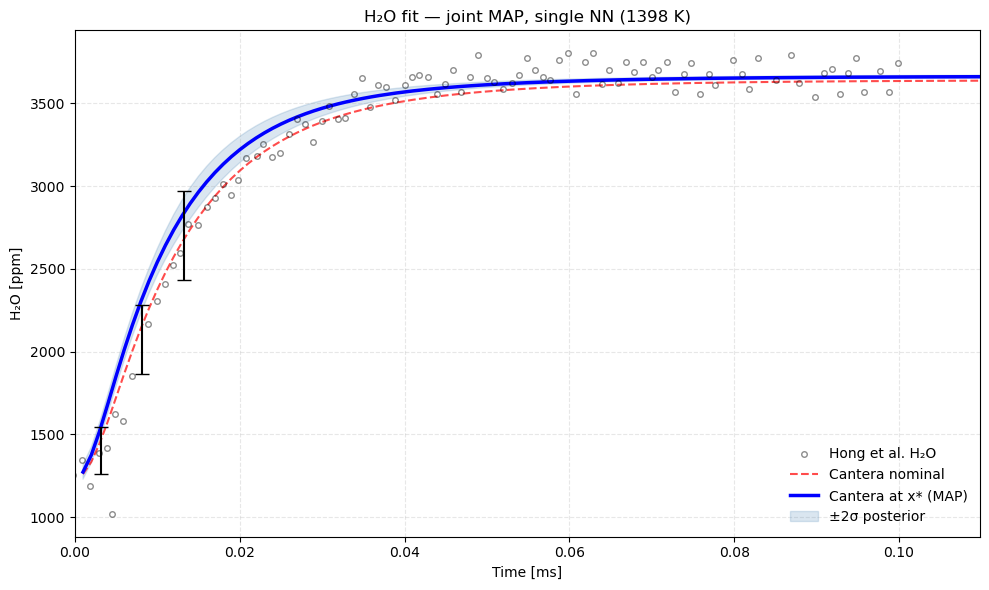

In [51]:
if not SYNTHETIC:
    y_exp_h2o_ppm = y_h2o_at_tgt * 1e6
    yerr_up = y_exp_h2o_ppm * (np.exp(+2*SIG_LOG) - 1)
    yerr_dn = y_exp_h2o_ppm * (1 - np.exp(-2*SIG_LOG))
h2o_xlim = max(t_h2o.max()*1e3 * 1.1, 0.06)   # auto-scale to the actual data range
                                              # instead of a hardcoded 1.0 ms -- at
                                              # 1398 K the reaction finishes ~10x faster

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_h2o["Time [ms]"], df_h2o["[H2O] ppm"], "o",
        mfc="none", mec="k", ms=4, alpha=0.45, zorder=3, label="Hong et al. H₂O")
if not SYNTHETIC:
    ax.errorbar(h2o_times*1e3, y_exp_h2o_ppm,
                yerr=[yerr_dn, yerr_up],
                fmt="none", ecolor="k", elinewidth=1.5, capsize=5, zorder=4)
ax.plot(T_SIM*1e3, h2o_nom*1e6, "r--", lw=1.5, alpha=0.7, label="Cantera nominal")
ax.plot(T_SIM*1e3, h2o_opt*1e6, "b-",  lw=2.5, label="Cantera at x* (MAP)")
ax.fill_between(T_SIM*1e3, h2o_lower*1e6, h2o_upper*1e6,
                color="steelblue", alpha=0.20, label="±2σ posterior")
ax.set(xlabel="Time [ms]", ylabel="H₂O [ppm]",
       xlim=[0, h2o_xlim], title="H₂O fit — joint MAP, single NN (1398 K)")
ax.legend(frameon=False); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout(); plt.show()


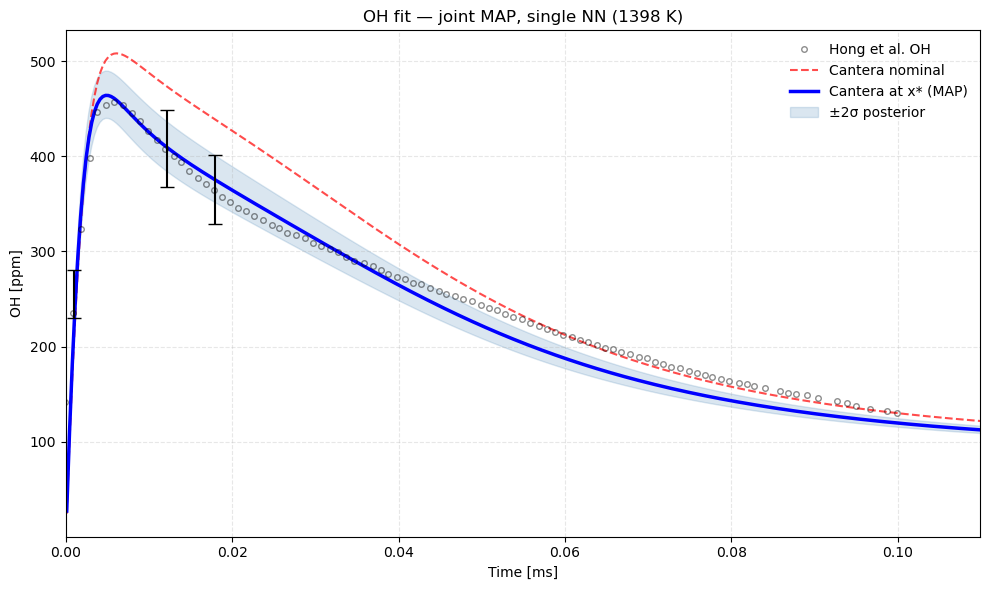

In [52]:
if not SYNTHETIC:
    y_exp_oh_ppm = y_oh_at_tgt * 1e6
    yerr_oh_up = y_exp_oh_ppm * (np.exp(+2*SIG_LOG) - 1)
    yerr_oh_dn = y_exp_oh_ppm * (1 - np.exp(-2*SIG_LOG))
oh_xlim = max(t_oh.max()*1e3 * 1.1, 0.06)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_oh["Time [ms]"], df_oh["[OH] ppm"], "o",
        mfc="none", mec="k", ms=4, alpha=0.45, zorder=3, label="Hong et al. OH")
if not SYNTHETIC:
    ax.errorbar(oh_times*1e3, y_exp_oh_ppm,
                yerr=[yerr_oh_dn, yerr_oh_up],
                fmt="none", ecolor="k", elinewidth=1.5, capsize=5, zorder=4)
ax.plot(T_OH*1e3, oh_nom*1e6, "r--", lw=1.5, alpha=0.7, label="Cantera nominal")
ax.plot(T_OH*1e3, oh_opt*1e6, "b-",  lw=2.5, label="Cantera at x* (MAP)")
ax.fill_between(T_OH*1e3, oh_lower*1e6, oh_upper*1e6,
                color="steelblue", alpha=0.20, label="±2σ posterior")
ax.set(xlabel="Time [ms]", ylabel="OH [ppm]",
       xlim=[0, oh_xlim], title="OH fit — joint MAP, single NN (1398 K)")
ax.legend(frameon=False); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout(); plt.show()


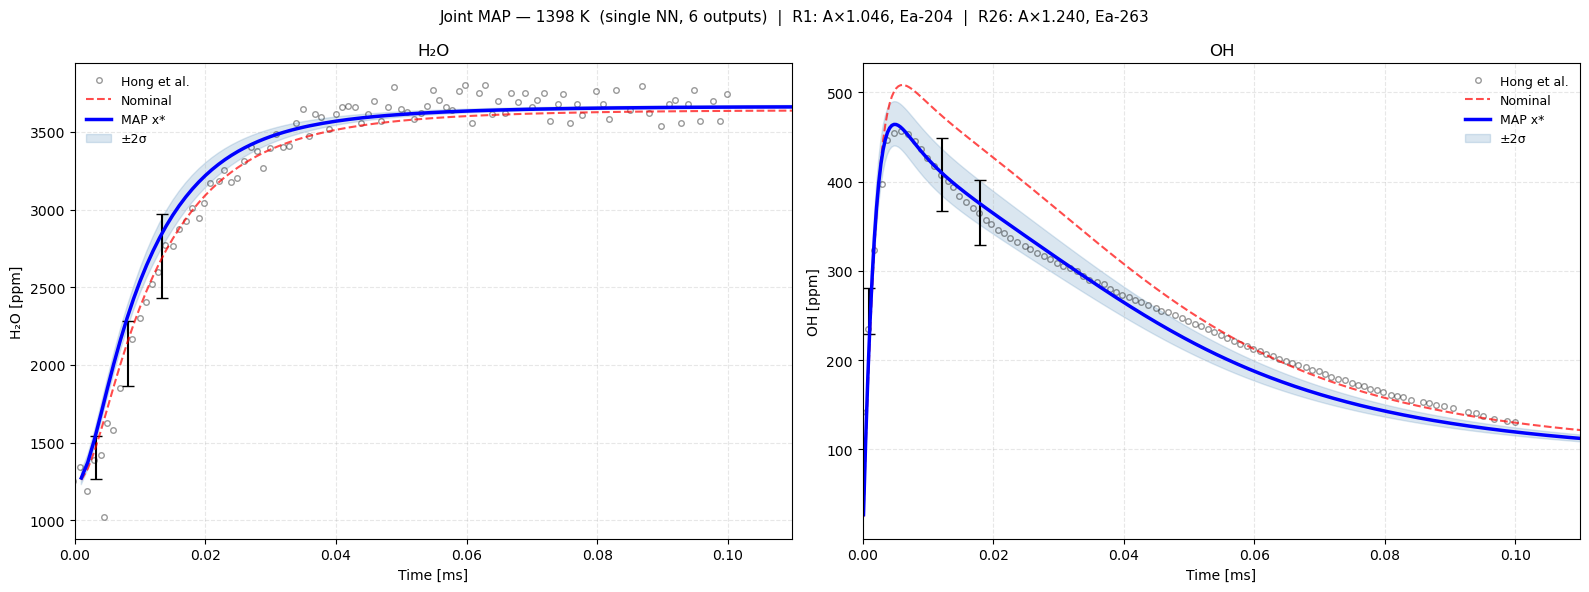

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(df_h2o["Time [ms]"], df_h2o["[H2O] ppm"], "o",
         mfc="none", mec="k", ms=4, alpha=0.4, label="Hong et al.")
if not SYNTHETIC:
    ax1.errorbar(h2o_times*1e3, y_exp_h2o_ppm,
                 yerr=[yerr_dn, yerr_up], fmt="none",
                 ecolor="k", elinewidth=1.5, capsize=4)
ax1.plot(T_SIM*1e3, h2o_nom*1e6, "r--", lw=1.5, alpha=0.7, label="Nominal")
ax1.plot(T_SIM*1e3, h2o_opt*1e6, "b-",  lw=2.5, label="MAP x*")
ax1.fill_between(T_SIM*1e3, h2o_lower*1e6, h2o_upper*1e6,
                 color="steelblue", alpha=0.20, label="±2σ")
ax1.set(xlabel="Time [ms]", ylabel="H₂O [ppm]", xlim=[0, h2o_xlim], title="H₂O")
ax1.legend(frameon=False, fontsize=9); ax1.grid(True, ls="--", alpha=0.3)

ax2.plot(df_oh["Time [ms]"], df_oh["[OH] ppm"], "o",
         mfc="none", mec="k", ms=4, alpha=0.4, label="Hong et al.")
if not SYNTHETIC:
    ax2.errorbar(oh_times*1e3, y_exp_oh_ppm,
                 yerr=[yerr_oh_dn, yerr_oh_up], fmt="none",
                 ecolor="k", elinewidth=1.5, capsize=4)
ax2.plot(T_OH*1e3, oh_nom*1e6, "r--", lw=1.5, alpha=0.7, label="Nominal")
ax2.plot(T_OH*1e3, oh_opt*1e6, "b-",  lw=2.5, label="MAP x*")
ax2.fill_between(T_OH*1e3, oh_lower*1e6, oh_upper*1e6,
                 color="steelblue", alpha=0.20, label="±2σ")
ax2.set(xlabel="Time [ms]", ylabel="OH [ppm]", xlim=[0, oh_xlim], title="OH")
ax2.legend(frameon=False, fontsize=9); ax2.grid(True, ls="--", alpha=0.3)

fig.suptitle(
    f"Joint MAP — 1398 K  (single NN, {N_TOTAL} outputs)  |  "
    f"R1: A×{np.exp(x_opt[0]*LN_F):.3f}, Ea{x_opt[1]*SIGMA_E:+.0f}  |  "
    f"R26: A×{np.exp(x_opt[2]*LN_F):.3f}, Ea{x_opt[3]*SIGMA_E:+.0f}",
    fontsize=11)
plt.tight_layout(); plt.show()
